In [1]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("../databases/lahman.db")

def run_query(query, params=None):
    return pd.read_sql_query(query, conn, params=params)

# Stage 2

## Part 1 - Basic SQL Practice

We'll use the Lahman tables People, Batting, Pitching and Teams

### Simplest queries

Question: What columns exist in Batting?

In [2]:
pd.read_sql_query("PRAGMA table_info(Batting);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,playerID,TEXT,0,None,1
1,1,yearID,INTEGER,0,None,2
2,2,stint,INTEGER,0,None,3
3,3,teamID,TEXT,0,None,0
4,4,lgID,TEXT,0,None,0
5,5,G,INTEGER,0,None,0
6,6,AB,INTEGER,0,None,0
7,7,R,INTEGER,0,None,0
8,8,H,INTEGER,0,None,0
9,9,2B,INTEGER,0,None,0


Question: Show first 10 batting records

In [3]:
query = """
SELECT *
FROM Batting
LIMIT 10;
"""
pd.read_sql_query(query, conn)

,playerID,yearID,stint,teamID,lgID,G,AB,R,H,2B,...,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP
0,aardsda01,2004,1,SFN,NL,11,0,0,0,0,...,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,aardsda01,2006,1,CHN,NL,45,2,0,0,0,...,0.0,0.0,0.0,0,0.0,0.0,0.0,1.0,0.0,0.0
2,aardsda01,2007,1,CHA,AL,25,0,0,0,0,...,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,aardsda01,2008,1,BOS,AL,47,1,0,0,0,...,0.0,0.0,0.0,0,1.0,0.0,0.0,0.0,0.0,0.0
4,aardsda01,2009,1,SEA,AL,73,0,0,0,0,...,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,aardsda01,2010,1,SEA,AL,53,0,0,0,0,...,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0
6,aardsda01,2012,1,NYA,AL,1,0,0,0,0,...,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0
7,aardsda01,2013,1,NYN,NL,43,0,0,0,0,...,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0
8,aardsda01,2015,1,ATL,NL,33,1,0,0,0,...,0.0,0.0,0.0,0,1.0,0.0,0.0,0.0,0.0,0.0
9,aaronha01,1954,1,ML1,NL,122,468,58,131,27,...,69.0,2.0,2.0,28,39.0,NaN,3.0,6.0,4.0,13.0


### WHERE

Question: Find batting stats for Barry Bonds in Pittsburgh

In [4]:
query = """
SELECT *
FROM Batting
WHERE playerID = 'bondsba01' AND teamID = 'PIT';
"""
pd.read_sql_query(query, conn)

,playerID,yearID,stint,teamID,lgID,G,AB,R,H,2B,...,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP
0,bondsba01,1986,1,PIT,NL,113,413,72,92,26,...,48.0,36.0,7.0,65,102.0,2.0,2.0,2.0,2.0,4.0
1,bondsba01,1987,1,PIT,NL,150,551,99,144,34,...,59.0,32.0,10.0,54,88.0,3.0,3.0,0.0,3.0,4.0
2,bondsba01,1988,1,PIT,NL,144,538,97,152,30,...,58.0,17.0,11.0,72,82.0,14.0,2.0,0.0,2.0,3.0
3,bondsba01,1989,1,PIT,NL,159,580,96,144,34,...,58.0,32.0,10.0,93,93.0,22.0,1.0,1.0,4.0,9.0
4,bondsba01,1990,1,PIT,NL,151,519,104,156,32,...,114.0,52.0,13.0,93,83.0,15.0,3.0,0.0,6.0,8.0
5,bondsba01,1991,1,PIT,NL,153,510,95,149,28,...,116.0,43.0,13.0,107,73.0,25.0,4.0,0.0,13.0,8.0
6,bondsba01,1992,1,PIT,NL,140,473,109,147,36,...,103.0,39.0,8.0,127,69.0,32.0,5.0,0.0,7.0,9.0


Question: Seasons with 45+ 2Bs and 45+ HRs

In [5]:
query = """
SELECT playerID, yearID, teamID, HR, "2B"
FROM Batting
WHERE HR > 44 and "2B" > 44
"""
pd.read_sql_query(query, conn)

,playerID,yearID,teamID,HR,2B
0,belleal01,1995,CLE,50,52
1,belleal01,1998,CHA,49,48
2,gehrilo01,1927,NYA,47,52
3,gonzaju03,1998,TEX,45,50
4,heltoto01,2001,COL,49,54
5,leede02,2005,CHN,46,50
6,pujolal01,2004,SLN,46,51
7,pujolal01,2009,SLN,47,45
8,walkela01,1997,COL,49,46


### ORDER BY

Question: Highest single-season home run totals

In [6]:
query = """
SELECT playerID, yearID, HR
FROM Batting
ORDER BY HR DESC
LIMIT 10;
"""
pd.read_sql_query(query, conn)

,playerID,yearID,HR
0,bondsba01,2001,73
1,mcgwima01,1998,70
2,sosasa01,1998,66
3,mcgwima01,1999,65
4,sosasa01,2001,64
5,sosasa01,1999,63
6,judgeaa01,2022,62
7,marisro01,1961,61
8,raleica01,2025,60
9,ruthba01,1927,60


Question: Top 10 highest single-season home run totals since 2015

In [7]:
query = """
SELECT playerID, yearID, HR
FROM Batting
WHERE yearID >= 2014
ORDER BY HR DESC
LIMIT 10;
"""
pd.read_sql_query(query, conn)

,playerID,yearID,HR
0,judgeaa01,2022,62
1,raleica01,2025,60
2,stantmi03,2017,59
3,judgeaa01,2024,58
4,schwaky01,2025,56
5,ohtansh01,2025,55
6,ohtansh01,2024,54
7,olsonma02,2023,54
8,alonspe01,2019,53
9,judgeaa01,2025,53


## Part 2 - GRUOUP BY and Aggregates

Career HR laders (600+)

In [8]:
query = """
SELECT playerID,
       SUM(HR) AS career_hr
FROM Batting
GROUP BY playerID
HAVING career_hr > 599
ORDER BY career_hr DESC
"""
pd.read_sql_query(query, conn)

,playerID,career_hr
0,bondsba01,762
1,aaronha01,755
2,ruthba01,714
3,pujolal01,703
4,rodrial01,696
5,mayswi01,660
6,griffke02,630
7,thomeji01,612
8,sosasa01,609


Avg. HRs per season by year

In [9]:
query = """
SELECT yearID,
       AVG(HR) AS avg_hr
FROM Batting
GROUP BY yearID
ORDER BY avg_hr DESC
LIMIT 10
"""
pd.read_sql_query(query, conn)

,yearID,avg_hr
0,2019,4.318674
1,1999,4.255581
2,1987,4.253817
3,2000,4.113439
4,2017,4.086345
5,2001,4.076176
6,2004,4.049777
7,1996,3.960096
8,1962,3.948684
9,2006,3.911402


Total runs by team in season

In [70]:
query = """
SELECT teamID,
       yearID,
       SUM(R) AS total_runs
FROM Batting
GROUP BY teamID, yearID
HAVING yearID > 1945 and total_runs > 1000
ORDER BY total_runs DESC
"""
pd.read_sql_query(query, conn)

,teamID,yearID,total_runs
0,BOS,1950,1027
1,CLE,1999,1009


## Part 3 - JOINSs

Career HR leaders with names

In [71]:
query = """
SELECT p.nameFirst,
       p.nameLast,
       SUM(b.HR) AS career_hr
FROM Batting b
JOIN People p
    ON b.playerID = p.playerID
GROUP BY b.playerID
ORDER BY career_hr DESC
LIMIT 10;
"""
pd.read_sql_query(query, conn)

,nameFirst,nameLast,career_hr
0,Barry,Bonds,762
1,Hank,Aaron,755
2,Babe,Ruth,714
3,Albert,Pujols,703
4,Alex,Rodriguez,696
5,Willie,Mays,660
6,Ken,Griffey,630
7,Jim,Thome,612
8,Sammy,Sosa,609
9,Frank,Robinson,586


Best Single Seasons

In [72]:
query = """
SELECT p.nameFirst,
       p.nameLast,
       b.yearID,
       b.HR
FROM Batting b
JOIN People p
    ON b.playerID = p.playerID
ORDER BY b.HR DESC
LIMIT 10;
"""
pd.read_sql_query(query, conn)

,nameFirst,nameLast,yearID,HR
0,Barry,Bonds,2001,73
1,Mark,McGwire,1998,70
2,Sammy,Sosa,1998,66
3,Mark,McGwire,1999,65
4,Sammy,Sosa,2001,64
5,Sammy,Sosa,1999,63
6,Aaron,Judge,2022,62
7,Roger,Maris,1961,61
8,Cal,Raleigh,2025,60
9,Babe,Ruth,1927,60


In [79]:
query = """
SELECT t.name,
       t.yearID,
       t.W,
       t.L
FROM Teams t
WHERE t.W > 109
ORDER BY t.W DESC
"""
pd.read_sql_query(query, conn)

,name,yearID,W,L
0,Chicago Cubs,1906,116,36
1,Seattle Mariners,2001,116,46
2,New York Yankees,1998,114,48
3,Cleveland Indians,1954,111,43
4,Los Angeles Dodgers,2022,111,51
5,Pittsburgh Pirates,1909,110,42
6,New York Yankees,1927,110,44


## Creating reusable query functions

In [80]:
def run_query(query, params=None):
    return pd.read_sql_query(query, conn, params=params)

## Mini Baseball Explorations

### Exploration 1: Who has the highest career batting average

In [87]:
query = """
SELECT p.nameFirst,
       p.nameLast,
       SUM(b.H) * 1.0 / SUM(b.AB) AS career_avg,
       SUM(b.AB) AS total_ab
FROM Batting b
JOIN People p
    ON b.playerID = p.playerID
WHERE b.yearID > 1945
GROUP BY b.playerID
HAVING total_ab > 5000
ORDER BY career_avg DESC
LIMIT 10;
"""
run_query(query)

,nameFirst,nameLast,career_avg,total_ab
0,Ted,Williams,0.340057,5602
1,Tony,Gwynn,0.338178,9288
2,Stan,Musial,0.328481,9273
3,Wade,Boggs,0.327887,9180
4,Rod,Carew,0.327751,9315
5,Kirby,Puckett,0.318056,7244
6,Vladimir,Guerrero,0.317597,8155
7,Roberto,Clemente,0.317326,9454
8,Todd,Helton,0.316378,7962
9,George,Kell,0.313568,5616


Let's look at players that had at least one season after 1945 

In [86]:
query = """
SELECT p.nameFirst,
       p.nameLast,
       SUM(b.H) * 1.0 / SUM(b.AB) AS career_avg,
       SUM(b.AB) AS total_ab
FROM Batting b
JOIN People p
    ON b.playerID = p.playerID
WHERE b.playerID IN (
    SELECT DISTINCT playerID
    FROM Batting
    WHERE yearID > 1945
)
GROUP BY b.playerID
HAVING SUM(b.AB) > 5000
ORDER BY career_avg DESC
LIMIT 10;
"""
run_query(query)

,nameFirst,nameLast,career_avg,total_ab
0,Ted,Williams,0.344407,7706
1,Tony,Gwynn,0.338178,9288
2,Stan,Musial,0.330842,10972
3,Wade,Boggs,0.327887,9180
4,Rod,Carew,0.327751,9315
5,Joe,DiMaggio,0.324586,6821
6,Joe,Medwick,0.323641,7635
7,Kirby,Puckett,0.318056,7244
8,Vladimir,Guerrero,0.317597,8155
9,Arky,Vaughan,0.317578,6622


### Exploration 2 - HR Explosion by Era

<Axes: xlabel='yearID'>

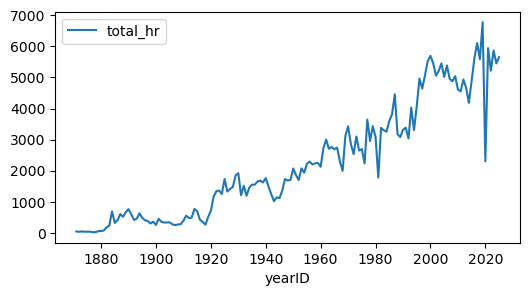

In [89]:
query = """
SELECT yearID,
       SUM(HR) AS total_hr
FROM Batting
GROUP BY yearID
ORDER BY yearID;
"""
df = run_query(query)

df.plot(x="yearID", y="total_hr", figsize=(6,3))

### Exploration 3 - Best teams ever by win %

In [93]:
query = """
SELECT name,
       yearID,
       W,
       L,
       (W * 1.0) / (W + L) AS win_pct
FROM Teams
WHERE (W + L) > 100 and yearID > 1900
ORDER BY win_pct DESC
LIMIT 10;
"""
run_query(query)

,name,yearID,W,L,win_pct
0,Chicago Cubs,1906,116,36,0.763158
1,Pittsburgh Pirates,1902,103,36,0.741007
2,Pittsburgh Pirates,1909,110,42,0.723684
3,Cleveland Indians,1954,111,43,0.720779
4,Seattle Mariners,2001,116,46,0.716049
5,New York Yankees,1927,110,44,0.714286
6,Chicago Cubs,1907,107,45,0.703947
7,Philadelphia Athletics,1931,107,45,0.703947
8,New York Yankees,1998,114,48,0.703704
9,New York Yankees,1939,106,45,0.701987


### Exercises

1. Career RBIs Leaders <br>
Find the top 10 players in career RBIs (Runs Batted In). Include player first and last names. Only consider players with at least 2000 at-bats.

In [ ]:
query = """
SELECT p.nameFirst,
       p.nameLast,
       SUM(b.RBI) AS career_rbi
FROM Batting b
JOIN People p
    ON b.playerID = p.playerID
GROUP BY b.playerID
HAVING SUM(b.AB) > 2000
ORDER BY career_rbi DESC
LIMIT 10;
"""
run_query(query)

,nameFirst,nameLast,career_rbi
0,Hank,Aaron,2297.0
1,Albert,Pujols,2218.0
2,Babe,Ruth,2217.0
3,Alex,Rodriguez,2086.0
4,Cap,Anson,2075.0
5,Barry,Bonds,1996.0
6,Lou,Gehrig,1995.0
7,Stan,Musial,1951.0
8,Ty,Cobb,1944.0
9,Jimmie,Foxx,1922.0


2. Highest Batting Average by Season <br>
For a single season, find the top 5 players with the highest batting average. Only include players with at least 100 at-bats that season. Include player names, year, and batting average.

In [ ]:
query = """
SELECT p.nameFirst,
       p.nameLast,
       b.yearID,
       SUM(b.H) * 1.0 / SUM(b.AB) AS avg
FROM Batting b
JOIN People p
    ON b.playerID = p.playerID
GROUP BY b.playerID, b.yearID
HAVING SUM(b.AB) > 100
ORDER BY avg DESC
LIMIT 5;
"""
run_query(query)

,nameFirst,nameLast,yearID,avg
0,Levi,Meyerle,1871,0.492308
1,Tetelo,Vargas,1943,0.471545
2,Josh,Gibson,1943,0.465863
3,Charlie,Smith,1927,0.456693
4,Charlie,Smith,1929,0.449393


3. Teams with Most Home Runs per Season <br>
Find the teams with the most total home runs in a season. Show team name, year, and total HR. Sort by total HR descending and show the top 10 results.

In [ ]:
query = """
SELECT teamID,
       yearID,
       SUM(HR) as total_hr
FROM Batting
GROUP BY teamID, yearID
ORDER BY total_hr DESC
LIMIT 10;
"""
run_query(query)

,teamID,yearID,total_hr
0,ATL,2023,307
1,MIN,2019,307
2,NYA,2019,306
3,HOU,2019,288
4,LAN,2019,279
5,NYA,2025,274
6,NYA,2018,267
7,SEA,1997,264
8,TOR,2021,262
9,TEX,2005,260


4. Stolen Base Trends Over Time <br>
Compute the total number of stolen bases per year across all players. Display the trend over time so you could plot a graph showing changes in stolen bases by year.

<Axes: xlabel='yearID'>

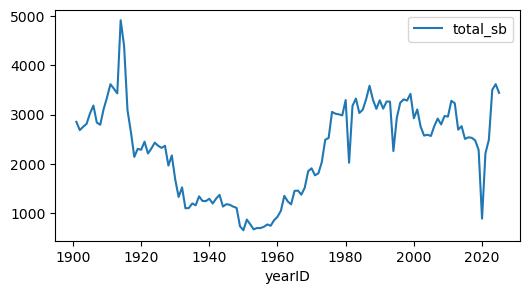

In [ ]:
query = """
SELECT yearID,
       SUM(SB) as total_sb
FROM Batting
WHERE yearID > 1900
GROUP BY yearID
ORDER BY yearID 
"""
df = run_query(query)

df.plot(x="yearID", y="total_sb", figsize=(6,3))

5. Multi-Category Leaders in a Single Season <br>
Find the players in a single season who had the most home runs and the most doubles combined. Include player names, year, total home runs, and total doubles. Sort by the sum of HR + 2B descending, showing the top 10.

### Exercises: Second batch

1. Career Slugging Leaders <br>
Find the top 10 career slugging percentage leaders.
Slugging % formula: (H + 2B + 2 * 3B + 3 * HR) / AB (simplified: sum total bases ÷ AB).
Only include players with at least 3000 AB.
Show player names, total AB, total bases, and slugging %.

2. Best Single-Season OPS Leaders <br>
OPS = On-Base % + Slugging %.
Find the top 10 single-season OPS performances.
Include player names, year, team, OBP, SLG, and OPS.
Only include seasons with at least 100 AB.
Hint: OBP = (H + BB + HBP) / (AB + BB + HBP + SF) — HBP and SF are columns in Lahman.

3. Era Comparison: Average Home Runs per Player <br>
Compare average HR per player per season between two eras:
Pre-1947 (before Jackie Robinson) vs Post-1947.
Only consider players with at least 50 AB in a season.
Show era, average HR per player, and total players counted.

4. Multi-Table: Pitchers on Winning Teams <br>
Find the pitchers who played for teams that won more than 90 games in a season, and list their total wins that season.
Include pitcher names, year, team, total wins.
Only consider seasons where the team had W > 90.
Sort descending by pitcher wins.

5. Career “Power-Speed” Players <br>
Identify players who excelled in both HR and SB in their careers.
Compute total HR and total SB per player.
Only include players with at least 1000 AB.
Show player names, career HR, career SB, and sum HR + SB.
Order descending by HR + SB.

"SELECT DISTINCT playerID AS player FROM Batting ORDER BY player"

In [169]:
query = """
SELECT DISTINCT playerID AS player 
FROM Batting 
WHERE yearID > 2023 and (lgID = 'AL' OR lgID = 'NL') and AB > 300
ORDER BY player
"""
run_query(query)

,player
0,abramcj01
1,abreuwi02
2,acunaro01
3,adamewi01
4,adelljo01
...,...
322,woodja03
323,yastrmi01
324,yelicch01
325,yoshima02


In [173]:
query = """SELECT DISTINCT teamID 
FROM Batting 
WHERE yearID > 2023 
ORDER BY teamID
"""
run_query(query)

,teamID
0,ARI
1,ATH
2,ATL
3,BAL
4,BOS
5,CHA
6,CHN
7,CIN
8,CLE
9,COL


In [174]:
query = """SELECT DISTINCT yearID FROM Batting WHERE yearID > 2023 ORDER BY yearID
"""
run_query(query)



,yearID
0,2024
1,2025
